
========== FIRST 5 ROWS ==========
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None

========== STATISTICAL SUMMARY ==========
    

/tmp/ipykernel_1968/3502252354.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_bill = df.groupby("day")["total_bill"].mean()


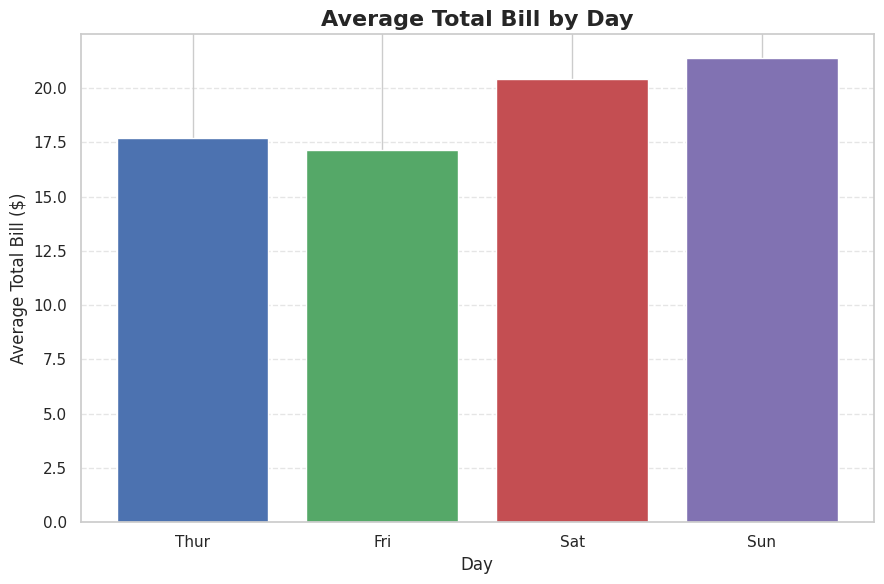

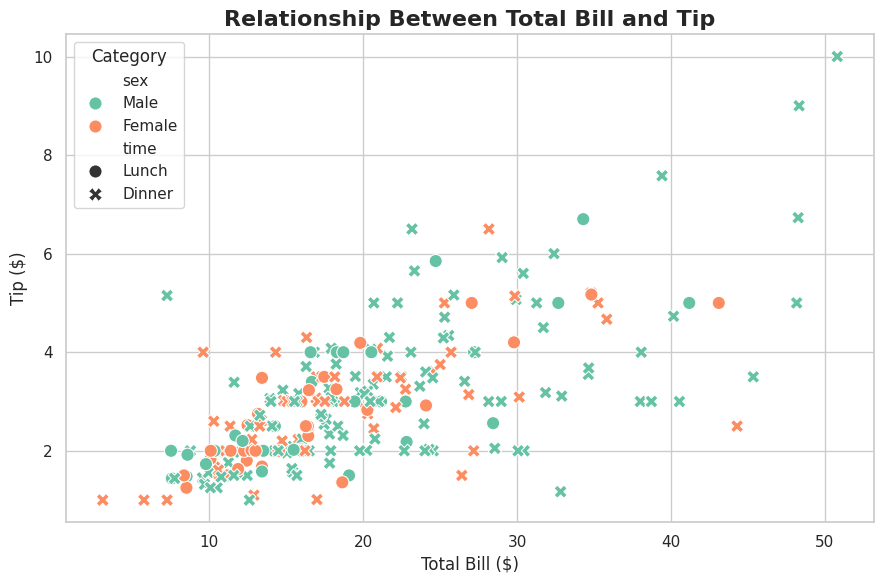

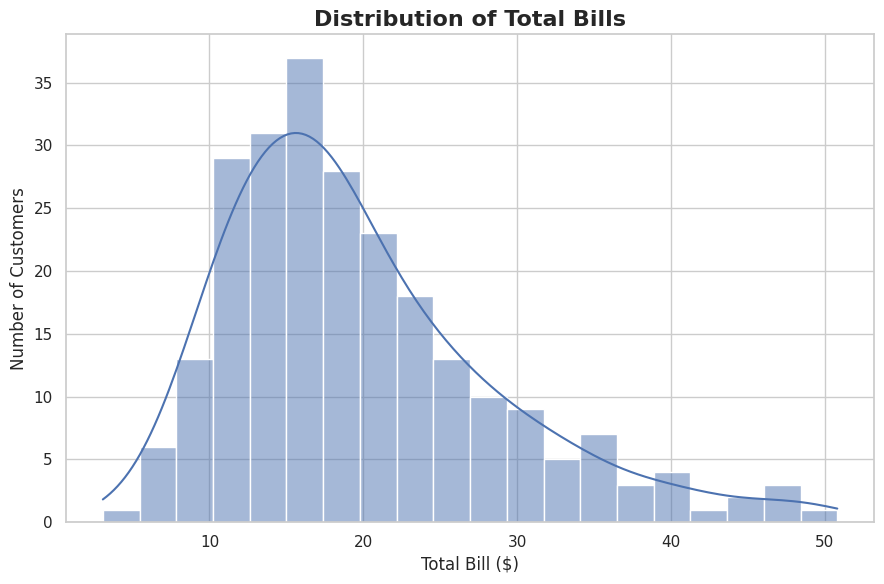

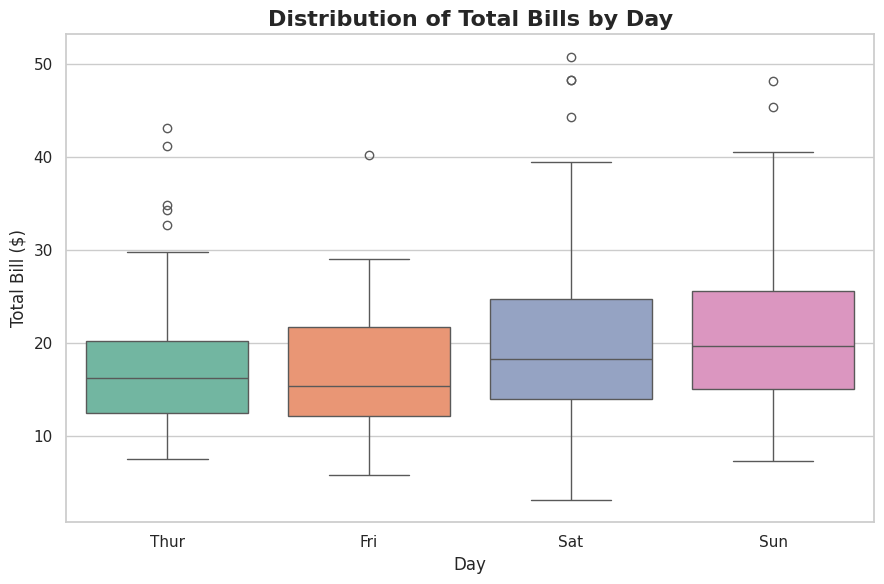


========== CORRELATION MATRIX ==========
            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


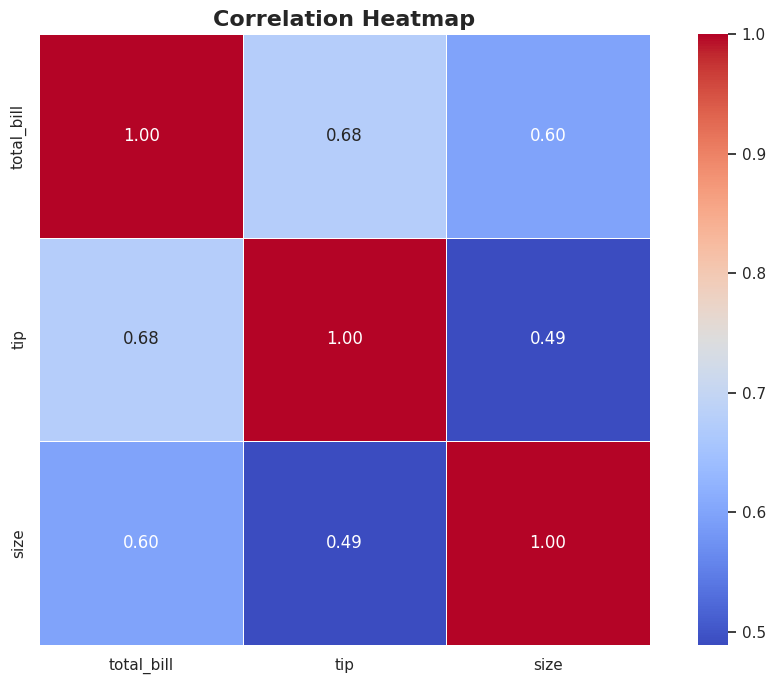

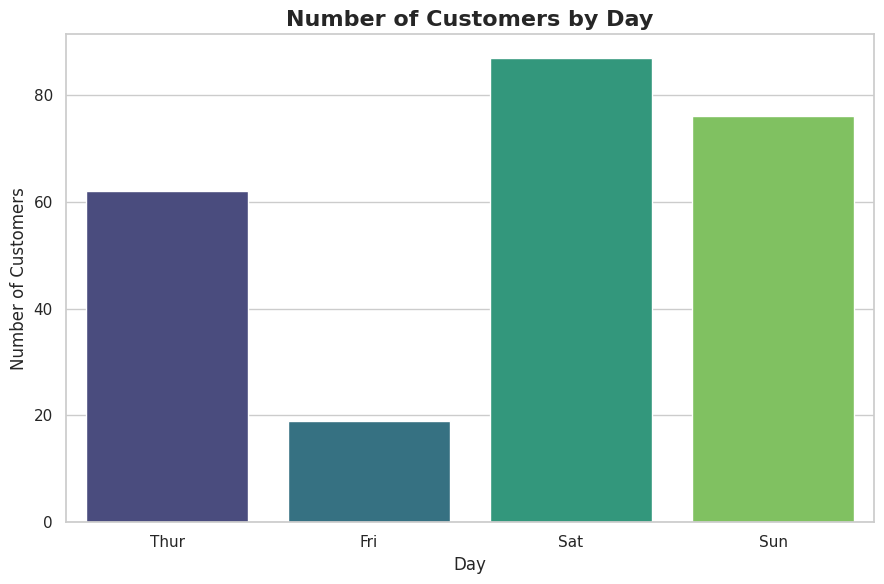

/tmp/ipykernel_1968/3502252354.py:254: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_tip = df.groupby("day")["tip"].mean().reset_index()


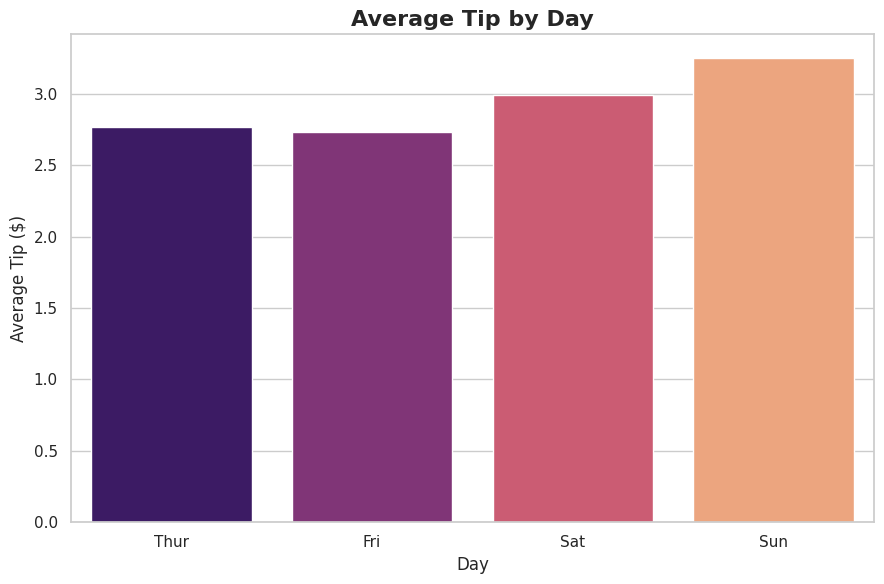

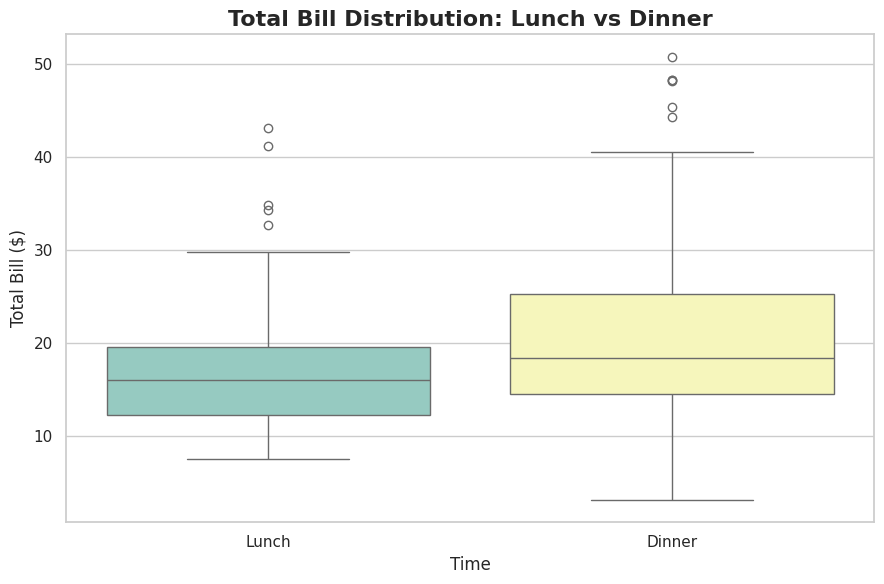

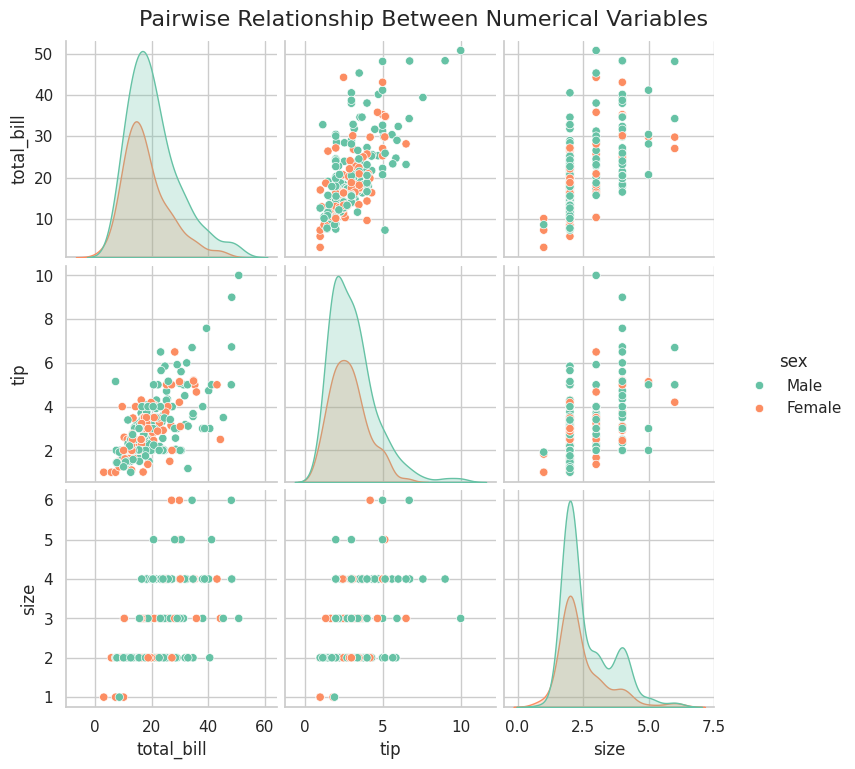


FINAL DATA ANALYSIS

Highest Total Bill:
total_bill     50.81
tip             10.0
sex             Male
smoker           Yes
day              Sat
time          Dinner
size               3
Name: 170, dtype: object

Highest Tip:
total_bill     50.81
tip             10.0
sex             Male
smoker           Yes
day              Sat
time          Dinner
size               3
Name: 170, dtype: object

Average Total Bill: 19.79
Average Tip: 3.0
Average Party Size: 2.57

Cleaned dataset saved as:
cleaned_tips_dataset.csv

PROJECT COMPLETED SUCCESSFULLY!


In [1]:
# ============================================================
# DATA VISUALIZATION WITH MATPLOTLIB & SEABORN
# ============================================================
# Project Features:
# 1. Bar Chart
# 2. Scatter Plot
# 3. Histogram
# 4. Box Plot
# 5. Correlation Matrix
# 6. Correlation Heatmap
# 7. Custom Color Palettes
# 8. Plot Formatting
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. SETUP
# ------------------------------------------------------------

# Set Seaborn style
sns.set_theme(style="whitegrid")

# Custom color palette
custom_palette = [
    "#4C72B0",
    "#55A868",
    "#C44E52",
    "#8172B2",
    "#CCB974",
    "#64B5CD"
]

# ------------------------------------------------------------
# 2. LOAD REAL DATASET
# ------------------------------------------------------------

# Seaborn's Tips dataset is a real restaurant dataset.
df = sns.load_dataset("tips")

# Display first few rows
print("\n========== FIRST 5 ROWS ==========")
print(df.head())

# Dataset information
print("\n========== DATASET INFORMATION ==========")
print(df.info())

# Statistical summary
print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

# Check missing values
print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

# ------------------------------------------------------------
# 3. BASIC DATA CLEANING
# ------------------------------------------------------------

# Remove rows containing missing values
df = df.dropna()

print("\nDataset shape after cleaning:")
print(df.shape)

# ------------------------------------------------------------
# 4. BAR CHART
# ------------------------------------------------------------

# Calculate average total bill for each day
average_bill = df.groupby("day")["total_bill"].mean()

plt.figure(figsize=(9, 6))

plt.bar(
    average_bill.index,
    average_bill.values,
    color=custom_palette[:len(average_bill)]
)

plt.title(
    "Average Total Bill by Day",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Day", fontsize=12)
plt.ylabel("Average Total Bill ($)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("01_bar_chart.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 5. SCATTER PLOT
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex",
    style="time",
    palette="Set2",
    s=90
)

plt.title(
    "Relationship Between Total Bill and Tip",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Tip ($)", fontsize=12)

plt.legend(title="Category")

plt.tight_layout()
plt.savefig("02_scatter_plot.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 6. HISTOGRAM
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.histplot(
    data=df,
    x="total_bill",
    bins=20,
    kde=True,
    color="#4C72B0"
)

plt.title(
    "Distribution of Total Bills",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.tight_layout()
plt.savefig("03_histogram.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 7. BOX PLOT
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="day",
    y="total_bill",
    hue="day",
    palette="Set2",
    legend=False
)

plt.title(
    "Distribution of Total Bills by Day",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Day", fontsize=12)
plt.ylabel("Total Bill ($)", fontsize=12)

plt.tight_layout()
plt.savefig("04_box_plot.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 8. CORRELATION MATRIX
# ------------------------------------------------------------

# Select numerical columns
numeric_data = df.select_dtypes(include=["number"])

# Calculate correlation
correlation_matrix = numeric_data.corr()

print("\n========== CORRELATION MATRIX ==========")
print(correlation_matrix)

# ------------------------------------------------------------
# 9. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f",
    square=True
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("05_correlation_heatmap.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 10. COUNT PLOT
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="day",
    hue="day",
    palette="viridis",
    legend=False
)

plt.title(
    "Number of Customers by Day",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Day", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.tight_layout()
plt.savefig("06_count_plot.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 11. AVERAGE TIP BY DAY
# ------------------------------------------------------------

average_tip = df.groupby("day")["tip"].mean().reset_index()

plt.figure(figsize=(9, 6))

sns.barplot(
    data=average_tip,
    x="day",
    y="tip",
    hue="day",
    palette="magma",
    legend=False
)

plt.title(
    "Average Tip by Day",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Day", fontsize=12)
plt.ylabel("Average Tip ($)", fontsize=12)

plt.tight_layout()
plt.savefig("07_average_tip.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 12. TOTAL BILL BY TIME
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="time",
    y="total_bill",
    hue="time",
    palette="Set3",
    legend=False
)

plt.title(
    "Total Bill Distribution: Lunch vs Dinner",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Time", fontsize=12)
plt.ylabel("Total Bill ($)", fontsize=12)

plt.tight_layout()
plt.savefig("08_lunch_dinner_boxplot.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 13. PAIR PLOT
# ------------------------------------------------------------

sns.pairplot(
    df,
    vars=["total_bill", "tip", "size"],
    hue="sex",
    palette="Set2"
)

plt.suptitle(
    "Pairwise Relationship Between Numerical Variables",
    y=1.02,
    fontsize=16
)

plt.savefig("09_pair_plot.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 14. FINAL DATA ANALYSIS
# ------------------------------------------------------------

print("\n========================================")
print("FINAL DATA ANALYSIS")
print("========================================")

# Highest bill
highest_bill = df.loc[df["total_bill"].idxmax()]

print("\nHighest Total Bill:")
print(highest_bill)

# Highest tip
highest_tip = df.loc[df["tip"].idxmax()]

print("\nHighest Tip:")
print(highest_tip)

# Average total bill
print(
    "\nAverage Total Bill:",
    round(df["total_bill"].mean(), 2)
)

# Average tip
print(
    "Average Tip:",
    round(df["tip"].mean(), 2)
)

# Average party size
print(
    "Average Party Size:",
    round(df["size"].mean(), 2)
)

# ------------------------------------------------------------
# 15. SAVE CLEANED DATASET
# ------------------------------------------------------------

df.to_csv("cleaned_tips_dataset.csv", index=False)

print("\nCleaned dataset saved as:")
print("cleaned_tips_dataset.csv")

print("\n========================================")
print("PROJECT COMPLETED SUCCESSFULLY!")
print("========================================")